# 🧍 Caso 2 — Segmentación de Clientes por Valor (Predicción de CLV)

---

## 🔴 Problema
Saber quién gastó mucho en el pasado no garantiza que lo siga haciendo mañana. Si das descuentos a clientes que solo compran cuando hay ofertas (cazadores de ofertas), erosionas tu margen sin generar valor a largo plazo.

## ❓ Pregunta de Negocio
> **"¿Qué grupos de clientes generarán la mayor parte de mis ingresos futuros?"**

## 🎯 Objetivo
- Cuantificar la billetera futura de cada cliente (Customer Lifetime Value - CLV).
- Pasar de un análisis descriptivo del pasado a una segmentación predictiva accionable.

## ⚙️ Propuesta Técnica
- Competencia de modelos predictivos de Regresión (Gradient Boosting, XGBoost, Random Forest).
- Análisis de Componentes Principales (PCA) para visualizar clústeres de valor.
- Análisis de variables clave (Feature Importance) y Correlaciones financieras.

## 📊 Dataset
Fuente: `TRAINING_DATASETS.OBT_CUSTOMER_LIFETIME_VALUE`
Features: `RANGO_EDAD`, `FEATURE_FREQ_TOTAL`, `FEATURE_CANTIDAD_ARTICULOS`, `FEATURE_ANTIGUEDAD_DIAS`
Target: `TARGET_CLV_HISTORICO`

---

## 1. 📦 Setup y Conexión

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import snowflake.connector
from dotenv import load_dotenv
import mlflow, mlflow.sklearn

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

load_dotenv()

current_path = os.getcwd()
mlflow.set_tracking_uri("sqlite:///mlflow.db")
print(f'✅ MLflow Tracking URI : sqlite:///mlflow.db')
print(f'✅ Entorno configurado correctamente')

✅ MLflow Tracking URI : sqlite:///mlflow.db
✅ Entorno configurado correctamente


In [2]:
conn = snowflake.connector.connect(
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
    database=os.getenv('SNOWFLAKE_DATABASE'),
    schema='TRAINING_DATASETS'
)

QUERY = 'SELECT * FROM TRAINING_DATASETS.OBT_CUSTOMER_LIFETIME_VALUE'
df_raw = pd.read_sql(QUERY, conn)
df_raw.columns = [c.upper() for c in df_raw.columns]
conn.close()

print(f'✅ Dataset cargado: {df_raw.shape[0]:,} filas | {df_raw.shape[1]} columnas')
print(f'💰 CLV histórico total: Bs {df_raw["TARGET_CLV_HISTORICO"].sum():,.1f}')
df_raw.head()

✅ Dataset cargado: 300,000 filas | 6 columnas
💰 CLV histórico total: Bs 321,349,679.0


,ID_CLIENTE_NK,RANGO_EDAD,FEATURE_FREQ_TOTAL,FEATURE_CANTIDAD_ARTICULOS,FEATURE_ANTIGUEDAD_DIAS,TARGET_CLV_HISTORICO
0,290804.0,Mayor de 35,11,26,3855,890.0
1,235472.0,18 - 25,14,36,3602,773.0
2,284335.0,Mayor de 35,10,27,3375,1184.0
3,125255.0,Mayor de 35,16,50,3909,2672.0
4,67956.0,Mayor de 35,16,35,3656,1080.0


## 2. 🔍 EDA — Análisis Exploratorio y Distribuciones

=== ESTADÍSTICAS DESCRIPTIVAS ===


,FEATURE_FREQ_TOTAL,FEATURE_CANTIDAD_ARTICULOS,FEATURE_ANTIGUEDAD_DIAS,TARGET_CLV_HISTORICO
count,300000.00,300000.00,300000.00,300000.00
mean,12.76,31.90,3654.92,1071.17
std,3.57,9.77,332.22,497.13
min,0.00,0.00,-54.00,0.00
25%,10.00,25.00,3525.00,705.00
50%,13.00,31.00,3757.00,1013.00
75%,15.00,38.00,3892.00,1372.00
max,32.00,86.00,3988.00,4319.00


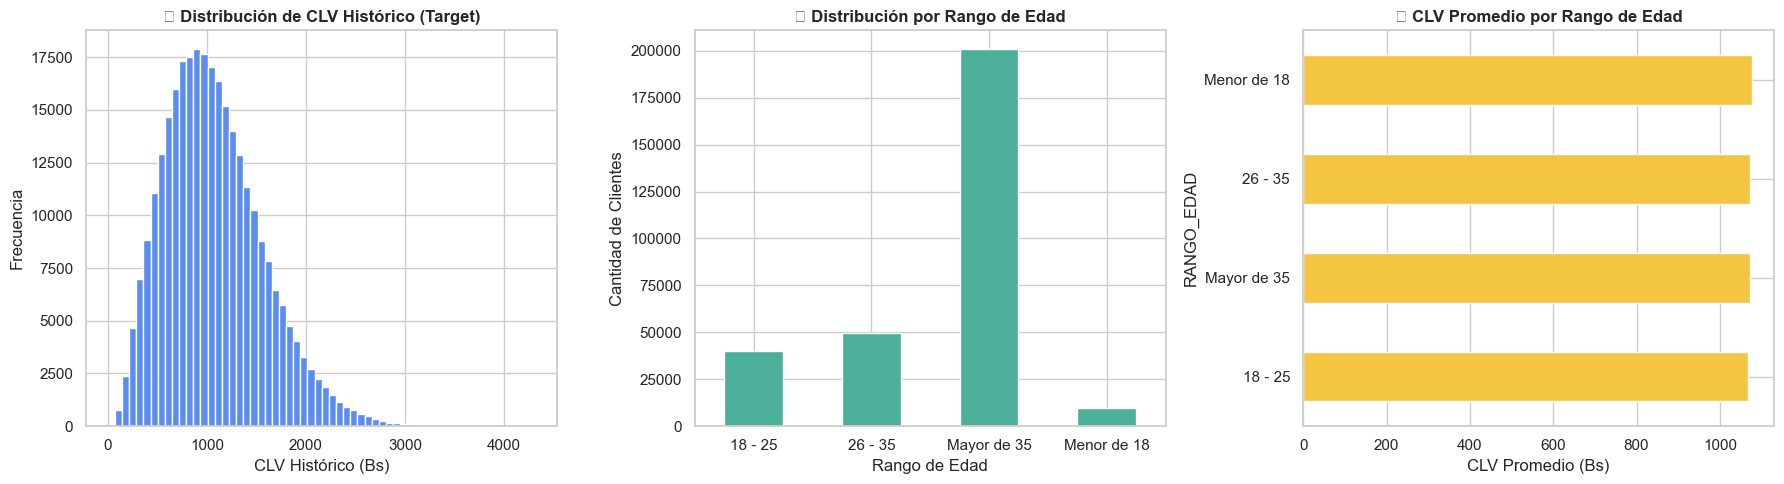

In [3]:
print('=== ESTADÍSTICAS DESCRIPTIVAS ===')
display(df_raw[['FEATURE_FREQ_TOTAL','FEATURE_CANTIDAD_ARTICULOS',
                'FEATURE_ANTIGUEDAD_DIAS','TARGET_CLV_HISTORICO']].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_raw['TARGET_CLV_HISTORICO'], bins=60, color='#5B8DEF', edgecolor='white')
axes[0].set_title('📊 Distribución de CLV Histórico (Target)', fontweight='bold')
axes[0].set_xlabel('CLV Histórico (Bs)')
axes[0].set_ylabel('Frecuencia')

df_raw['RANGO_EDAD'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='#4CAF9A', edgecolor='white')
axes[1].set_title('👥 Distribución por Rango de Edad', fontweight='bold')
axes[1].set_xlabel('Rango de Edad')
axes[1].set_ylabel('Cantidad de Clientes')
axes[1].tick_params(axis='x', rotation=0)

clv_por_edad = df_raw.groupby('RANGO_EDAD')['TARGET_CLV_HISTORICO'].mean().sort_values()
clv_por_edad.plot(kind='barh', ax=axes[2], color='#F4C542', edgecolor='white')
axes[2].set_title('💰 CLV Promedio por Rango de Edad', fontweight='bold')
axes[2].set_xlabel('CLV Promedio (Bs)')

plt.tight_layout()
plt.savefig('clv_eda.png', dpi=150, bbox_inches='tight')
plt.show()

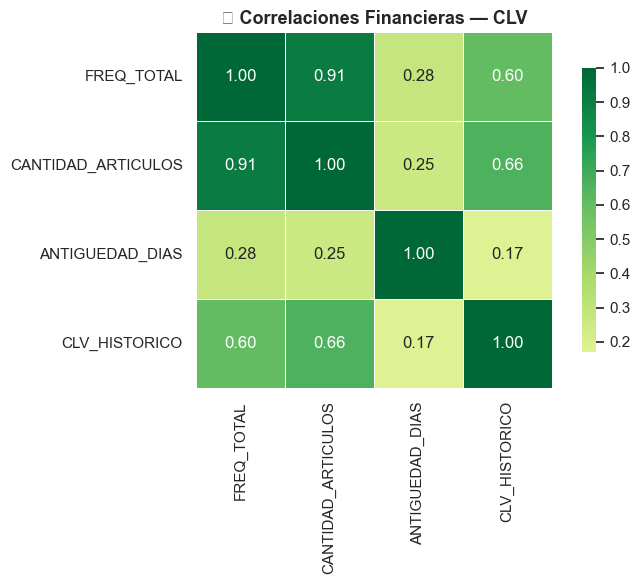


💡 Hallazgos clave de correlación:
   • CANTIDAD_ARTICULOS                  → +0.6600
   • FREQ_TOTAL                          → +0.6026
   • ANTIGUEDAD_DIAS                     → +0.1694


In [4]:
FEATURE_COLS = ['FEATURE_FREQ_TOTAL','FEATURE_CANTIDAD_ARTICULOS',
                'FEATURE_ANTIGUEDAD_DIAS','TARGET_CLV_HISTORICO']

corr_matrix = df_raw[FEATURE_COLS].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
    xticklabels=[c.replace('FEATURE_','').replace('TARGET_','') for c in FEATURE_COLS],
    yticklabels=[c.replace('FEATURE_','').replace('TARGET_','') for c in FEATURE_COLS]
)
plt.title('🔗 Correlaciones Financieras — CLV', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('clv_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 Hallazgos clave de correlación:')
corr_target = corr_matrix['TARGET_CLV_HISTORICO'].drop('TARGET_CLV_HISTORICO').sort_values(ascending=False)
for feat, val in corr_target.items():
    print(f'   • {feat.replace("FEATURE_",""):<35} → {val:+.4f}')

## 3. 🔬 PCA — Visualización de Clústeres de Valor

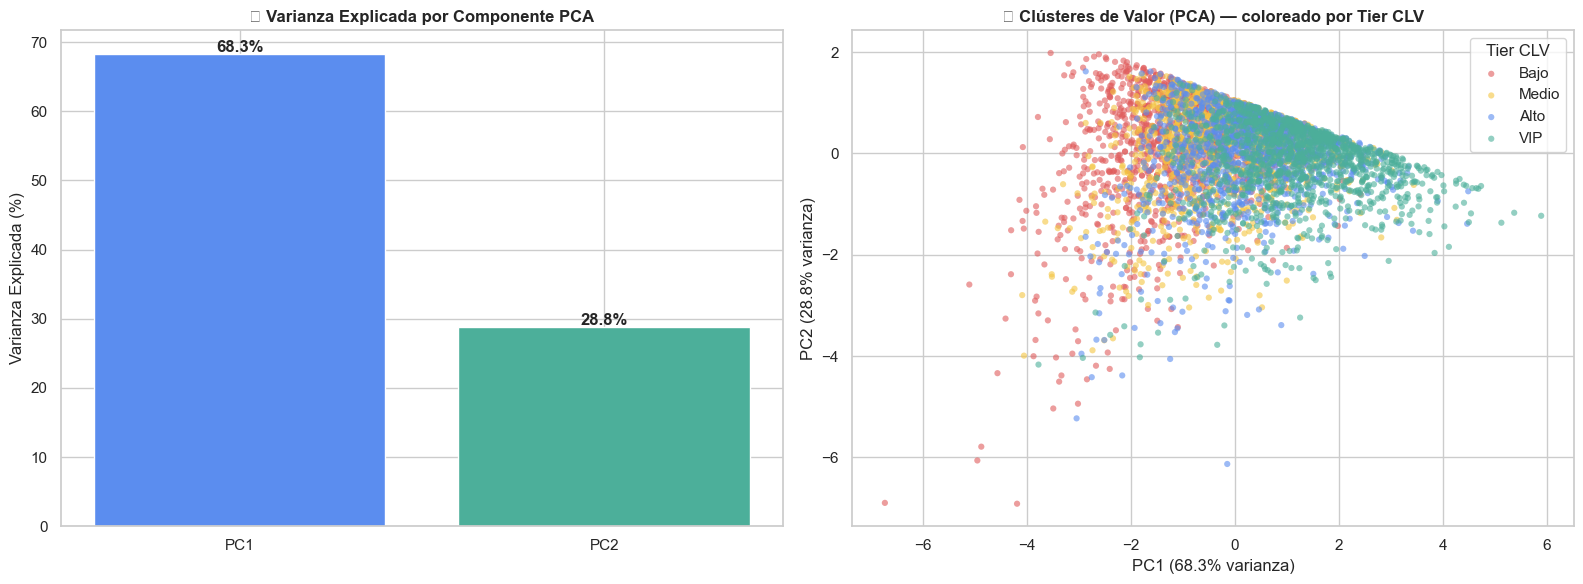

✅ Varianza total explicada (PC1+PC2): 97.1%


In [5]:
numeric_cols = ['FEATURE_FREQ_TOTAL','FEATURE_CANTIDAD_ARTICULOS','FEATURE_ANTIGUEDAD_DIAS']
X_numeric = df_raw[numeric_cols].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Definir percentiles de CLV para colorear
clv_vals = df_raw['TARGET_CLV_HISTORICO'].values
percentiles = np.percentile(clv_vals, [0, 25, 50, 75, 100])
tier_labels = pd.cut(clv_vals, bins=percentiles, labels=['Bajo','Medio','Alto','VIP'],
                     include_lowest=True)

colores_tier = {'Bajo': '#E05C5C', 'Medio': '#F4C542', 'Alto': '#5B8DEF', 'VIP': '#4CAF9A'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Varianza explicada
axes[0].bar(['PC1','PC2'], pca.explained_variance_ratio_ * 100,
            color=['#5B8DEF','#4CAF9A'], edgecolor='white')
axes[0].set_title('📐 Varianza Explicada por Componente PCA', fontweight='bold')
axes[0].set_ylabel('Varianza Explicada (%)')
for i, v in enumerate(pca.explained_variance_ratio_ * 100):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Scatter PCA por tier de CLV
sample_idx = np.random.choice(len(X_pca), min(5000, len(X_pca)), replace=False)
for tier in ['Bajo','Medio','Alto','VIP']:
    mask = np.array(tier_labels == tier)
    idx = np.where(mask)[0]
    idx = np.intersect1d(idx, sample_idx)
    axes[1].scatter(X_pca[idx, 0], X_pca[idx, 1],
                    c=colores_tier[tier], label=tier, alpha=0.6, s=20, edgecolors='none')

axes[1].set_title('🔬 Clústeres de Valor (PCA) — coloreado por Tier CLV', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')
axes[1].legend(title='Tier CLV', loc='upper right')

plt.tight_layout()
plt.savefig('clv_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Varianza total explicada (PC1+PC2): {sum(pca.explained_variance_ratio_)*100:.1f}%')

## 4. 🏆 Competencia de Modelos de Regresión

In [6]:
FEATURE_COLS_MODEL = ['RANGO_EDAD','FEATURE_FREQ_TOTAL',
                      'FEATURE_CANTIDAD_ARTICULOS','FEATURE_ANTIGUEDAD_DIAS']
TARGET_COL = 'TARGET_CLV_HISTORICO'

X = df_raw[FEATURE_COLS_MODEL].copy()
y = df_raw[TARGET_COL].fillna(0).copy()
X['RANGO_EDAD'] = X['RANGO_EDAD'].fillna('Desconocido')
for c in ['FEATURE_FREQ_TOTAL','FEATURE_CANTIDAD_ARTICULOS','FEATURE_ANTIGUEDAD_DIAS']:
    X[c] = X[c].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_features  = ['RANGO_EDAD']
num_features  = ['FEATURE_FREQ_TOTAL','FEATURE_CANTIDAD_ARTICULOS','FEATURE_ANTIGUEDAD_DIAS']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

MODELS = {
    "LinearRegression":  LinearRegression(),
    "Ridge":             Ridge(alpha=1.0),
    "RandomForest":      RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    "GradientBoosting":  GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=100, max_depth=5, random_state=42),
}

mlflow.set_experiment("HGC_CLV_Notebook_Caso2")

resultados = {}
print(f"{'Modelo':<25} {'R²':>8} {'MAE':>12} {'RMSE':>12}")
print("-" * 60)

for nombre, modelo in MODELS.items():
    with mlflow.start_run(run_name=nombre):
        pipeline = Pipeline([('pre', preprocessor), ('reg', modelo)])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        r2   = r2_score(y_test, y_pred)
        mae  = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mlflow.log_metrics({'r2': r2, 'mae': mae, 'rmse': rmse})
        resultados[nombre] = {'pipeline': pipeline, 'r2': r2, 'mae': mae, 'rmse': rmse}
        print(f"  {nombre:<23} {r2:>8.4f} {mae:>10.2f} Bs {rmse:>10.2f} Bs")

campeon_nombre = max(resultados, key=lambda m: resultados[m]['r2'])
campeon = resultados[campeon_nombre]
print(f"\n✅ MODELO CAMPEÓN: {campeon_nombre}  (R²={campeon['r2']:.4f}, MAE={campeon['mae']:.2f} Bs)")

2026/04/21 15:39:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/04/21 15:39:59 INFO mlflow.store.db.utils: Updating database tables


2026/04/21 15:40:01 INFO mlflow.tracking.fluent: Experiment with name 'HGC_CLV_Notebook_Caso2' does not exist. Creating a new experiment.


Modelo                          R²          MAE         RMSE
------------------------------------------------------------


  LinearRegression          0.4357     296.01 Bs     374.32 Bs


  Ridge                     0.4357     296.01 Bs     374.32 Bs


  RandomForest              0.4343     296.30 Bs     374.78 Bs


  GradientBoosting          0.4352     296.13 Bs     374.47 Bs


  XGBoost                   0.4339     296.45 Bs     374.93 Bs

✅ MODELO CAMPEÓN: LinearRegression  (R²=0.4357, MAE=296.01 Bs)


## 5. 📊 Feature Importance — ¿Qué impulsa el CLV?

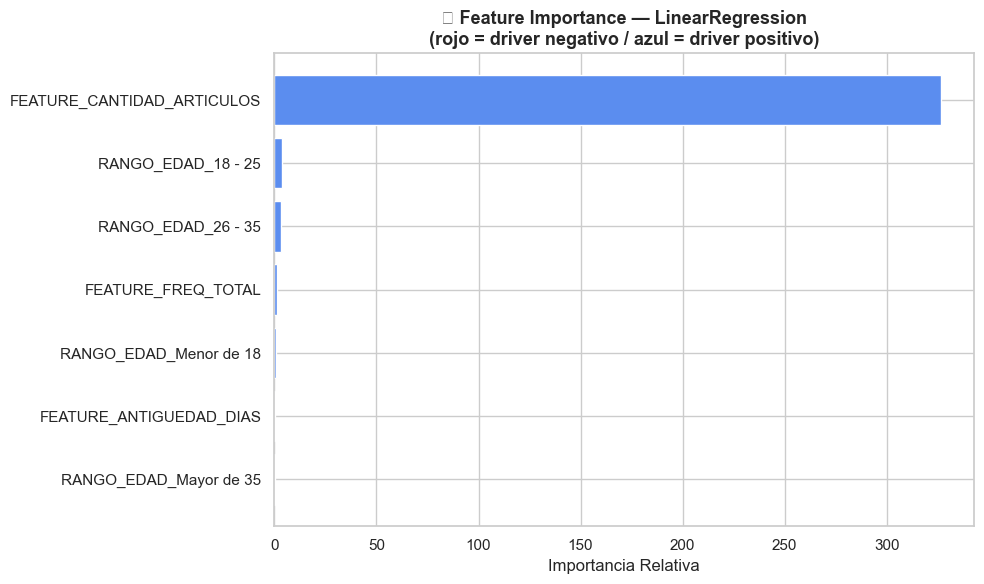


💡 Interpretación de Negocio:
   • Las variables con mayor importancia son los motores del CLV futuro.
   • Variables con baja importancia pueden ser candidatas a simplificación del modelo.


In [7]:
campeon_pipeline = campeon['pipeline']

# Extraer importancias si el modelo las tiene
try:
    reg_model = campeon_pipeline.named_steps['reg']
    if hasattr(reg_model, 'feature_importances_'):
        importances = reg_model.feature_importances_
    elif hasattr(reg_model, 'coef_'):
        importances = np.abs(reg_model.coef_)
    else:
        importances = None
    
    if importances is not None:
        pre = campeon_pipeline.named_steps['pre']
        num_names = num_features
        cat_names = list(pre.named_transformers_['cat'].get_feature_names_out(cat_features))
        all_names = num_names + cat_names
        
        fi_df = pd.DataFrame({'feature': all_names, 'importance': importances})
        fi_df = fi_df.sort_values('importance', ascending=True).tail(10)
        
        colores_fi = ['#E05C5C' if 'DESCUENTO' in f.upper() or 'DESC' in f.upper() 
                      else '#5B8DEF' for f in fi_df['feature']]
        
        plt.figure(figsize=(10, 6))
        bars = plt.barh(fi_df['feature'], fi_df['importance'], color=colores_fi, edgecolor='white')
        plt.title(f'🔑 Feature Importance — {campeon_nombre}\n(rojo = driver negativo / azul = driver positivo)',
                  fontweight='bold', fontsize=13)
        plt.xlabel('Importancia Relativa')
        plt.tight_layout()
        plt.savefig('clv_feature_importance.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print("\n💡 Interpretación de Negocio:")
        print(f"   • Las variables con mayor importancia son los motores del CLV futuro.")
        print(f"   • Variables con baja importancia pueden ser candidatas a simplificación del modelo.")
except Exception as e:
    print(f"Feature Importance no disponible para este modelo: {e}")

## 6. 💰 Segmentación Accionable — VIP vs Cazadores de Ofertas

In [8]:
df_result = df_raw[FEATURE_COLS_MODEL + [TARGET_COL]].copy()
df_result['CLV_PREDICHO'] = campeon_pipeline.predict(X)

p80 = df_result['CLV_PREDICHO'].quantile(0.80)
p20 = df_result['CLV_PREDICHO'].quantile(0.20)

df_result['SEGMENTO'] = 'Estándar'
df_result.loc[df_result['CLV_PREDICHO'] >= p80, 'SEGMENTO'] = 'VIP (Acción Cross-Sell)'
df_result.loc[df_result['CLV_PREDICHO'] <= p20, 'SEGMENTO'] = 'Riesgo (Contener Descuentos)'

resumen_seg = df_result.groupby('SEGMENTO').agg(
    clientes=('CLV_PREDICHO', 'count'),
    clv_total_proyectado=('CLV_PREDICHO', 'sum'),
    clv_promedio=('CLV_PREDICHO', 'mean')
).reset_index()

print('\n' + '='*70)
print('  📊 RESULTADOS: Caso 2 — Segmentación Predictiva de CLV')
print('='*70)
print(f'  Clientes analizados : {len(df_result):,}')
print(f'  CLV histórico total : Bs {df_result[TARGET_COL].sum():,.1f}')
print(f'  Modelo campeón      : {campeon_nombre}')
print(f'  R² Score            : {campeon["r2"]:.4f}')
print(f'  MAE                 : Bs {campeon["mae"]:.2f}')
print()

ACCIONES = {
    'VIP (Acción Cross-Sell)':          ('💎', 'Campañas premium, cross-selling, trato personalizado'),
    'Estándar':                          ('👤', 'Nutrición progresiva — fidelización gradual'),
    'Riesgo (Contener Descuentos)':     ('⚠️', 'Bloquear cupones agresivos — evaluar retención estratégica'),
}

for _, row in resumen_seg.sort_values('clv_total_proyectado', ascending=False).iterrows():
    seg = row['SEGMENTO']
    emoji, accion = ACCIONES.get(seg, ('🔹', ''))
    print(f"  {emoji} {seg}")
    print(f"     Clientes          : {row['clientes']:,} ({row['clientes']/len(df_result)*100:.1f}%)")
    print(f"     CLV Total Proy.   : Bs {row['clv_total_proyectado']:,.0f}")
    print(f"     CLV Promedio      : Bs {row['clv_promedio']:,.0f}")
    print(f"     💡 Acción         : {accion}")
    print()

print('='*70)


  📊 RESULTADOS: Caso 2 — Segmentación Predictiva de CLV
  Clientes analizados : 300,000
  CLV histórico total : Bs 321,349,679.0
  Modelo campeón      : LinearRegression
  R² Score            : 0.4357
  MAE                 : Bs 296.01

  👤 Estándar
     Clientes          : 180,000 (60.0%)
     CLV Total Proy.   : Bs 190,149,165
     CLV Promedio      : Bs 1,056
     💡 Acción         : Nutrición progresiva — fidelización gradual

  💎 VIP (Acción Cross-Sell)
     Clientes          : 60,000 (20.0%)
     CLV Total Proy.   : Bs 93,001,647
     CLV Promedio      : Bs 1,550
     💡 Acción         : Campañas premium, cross-selling, trato personalizado

  ⚠️ Riesgo (Contener Descuentos)
     Clientes          : 60,000 (20.0%)
     CLV Total Proy.   : Bs 38,089,287
     CLV Promedio      : Bs 635
     💡 Acción         : Bloquear cupones agresivos — evaluar retención estratégica



## 7. 🚀 Instrucciones para Serving

El modelo CLV ya está registrado en MLflow bajo el nombre `HGC_CLV_Model_Pro` y sirve en producción.

```bash
# Desde hgc-ml/
python serve_clv.py
```

Expone el endpoint en `http://127.0.0.1:5003/invocations` que el backend (`ml.controller.js → predictCLV`) utiliza.

**Payload esperado:**
```json
{
  "dataframe_split": {
    "columns": ["RANGO_EDAD","FEATURE_FREQ_TOTAL","FEATURE_CANTIDAD_ARTICULOS","FEATURE_ANTIGUEDAD_DIAS"],
    "data": [["36-45", 25, 80, 720]]
  }
}
```

> **Nota:** El backend aplica adicionalmente multiplicadores demográficos de negocio post-predicción para reflejar curvas de poder adquisitivo por edad.